In [3]:
pip install geopandas

Note: you may need to restart the kernel to use updated packages.


In [17]:
pip install folium

Note: you may need to restart the kernel to use updated packages.


In [19]:
# ================================
# PART 1: IMPORT & LOAD DATA
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')

# Load your dataset
df = pd.read_csv("amr patterns 2020 to 2023.csv")

# Preview the first rows
print(df.head())

# Ensure correct datatypes
df['CountryTerritoryArea'] = df['CountryTerritoryArea'].astype(str)


      Specimen           PathogenName  AntibioticName Iso3  \
0  Bloodstream  Klebsiella pneumoniae     Ceftriaxone  BFA   
1  Bloodstream  Klebsiella pneumoniae   Ciprofloxacin  BFA   
2  Bloodstream  Klebsiella pneumoniae  Co-trimoxazole  BFA   
3  Bloodstream  Klebsiella pneumoniae        Imipenem  BFA   
4  Bloodstream  Klebsiella pneumoniae        Cefepime  CIV   

          CountryTerritoryArea   WHORegionName  InterpretableAST  Resistant  \
0                 Burkina Faso  African Region                27         24   
1                 Burkina Faso  African Region                35         18   
2                 Burkina Faso  African Region                37         34   
3                 Burkina Faso  African Region                32          0   
4  C<U+00F4>te d<U+2019>Ivoire  African Region                11         11   

   ResistancePercentage  Year  
0             88.888889  2020  
1             51.428571  2020  
2             91.891892  2020  
3              0.000000 

In [21]:
# ================================
# PART 2: BASIC SUMMARY & OVERVIEW
# ================================

print("\n--- DATA INFO ---")
print(df.info())

print("\n--- SUMMARY STATISTICS ---")
print(df.describe())

print("\nNumber of countries:", df['CountryTerritoryArea'].nunique())
print("Number of antibiotics:", df['AntibioticName'].nunique())
print("Number of pathogens:", df['PathogenName'].nunique())
print("Years in the dataset:", sorted(df['Year'].unique()))


--- DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Specimen              450 non-null    object 
 1   PathogenName          450 non-null    object 
 2   AntibioticName        450 non-null    object 
 3   Iso3                  450 non-null    object 
 4   CountryTerritoryArea  450 non-null    object 
 5   WHORegionName         450 non-null    object 
 6   InterpretableAST      450 non-null    int64  
 7   Resistant             450 non-null    int64  
 8   ResistancePercentage  450 non-null    float64
 9   Year                  450 non-null    int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 35.3+ KB
None

--- SUMMARY STATISTICS ---
       InterpretableAST    Resistant  ResistancePercentage         Year
count        450.000000   450.000000            450.000000   450.000000
mean         608.966667 

In [25]:
# ============================================
# PART 3A: MEAN RESISTANCE BY COUNTRY
# ============================================

country_res = (
    df.groupby('CountryTerritoryArea')['ResistancePercentage']
      .mean()
      .sort_values(ascending=False)
)

print("\n--- MEAN RESISTANCE BY COUNTRY ---")
print(country_res)


--- MEAN RESISTANCE BY COUNTRY ---
CountryTerritoryArea
Democratic Republic of the Congo    70.119311
Malawi                              67.760858
Liberia                             66.668138
Nigeria                             64.609612
Benin                               63.815219
C<U+00F4>te d<U+2019>Ivoire         63.719771
Ghana                               61.274679
United Republic of Tanzania         60.732053
Ethiopia                            60.669944
Burkina Faso                        60.155136
Kenya                               59.189021
Zambia                              57.705832
Cameroon                            56.717866
Mozambique                          54.245109
Rwanda                              53.890748
Madagascar                          53.119658
Mauritius                           52.841359
Eswatini                            52.814322
Uganda                              52.468606
Mali                                49.549106
South Africa           

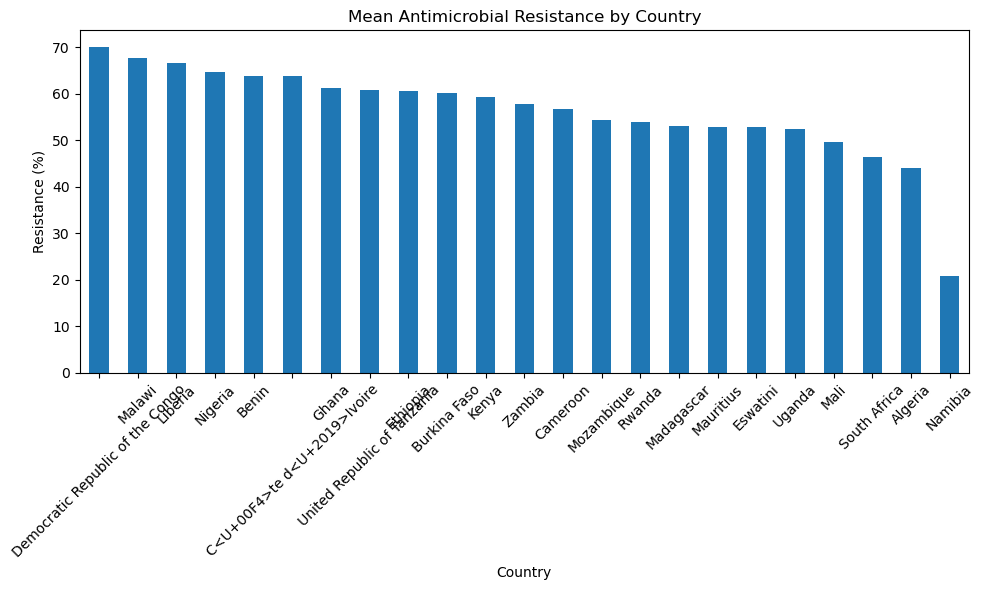

In [27]:
# ============================================
# PART 3B: PLOT MEAN RESISTANCE BY COUNTRY
# ============================================

plt.figure(figsize=(10,6))
country_res.plot(kind='bar')
plt.title("Mean Antimicrobial Resistance by Country")
plt.ylabel("Resistance (%)")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
save_path=r"C:\Users\owner\Downloads\Mean Antimicrobial Resistance by Country.png"
plt.savefig(save_path, dpi=300)
plt.show()

In [9]:
# ============================================
# PART 4A: MEAN RESISTANCE BY ANTIBIOTIC
# ============================================

abx_res = (
    df.groupby('AntibioticName')['ResistancePercentage']
      .mean()
      .sort_values(ascending=False)
)

print("\n--- MEAN RESISTANCE BY ANTIBIOTIC ---")
print(abx_res)


--- MEAN RESISTANCE BY ANTIBIOTIC ---
AntibioticName
Ceftriaxone       83.211247
Co-trimoxazole    80.158149
Cefotaxime        79.167074
Ceftazidime       73.597795
Cefepime          66.455012
Ciprofloxacin     56.286535
Levofloxacin      42.412996
Ertapenem         21.020802
Meropenem         20.178341
Colistin          18.122698
Imipenem          15.222065
Name: ResistancePercentage, dtype: float64


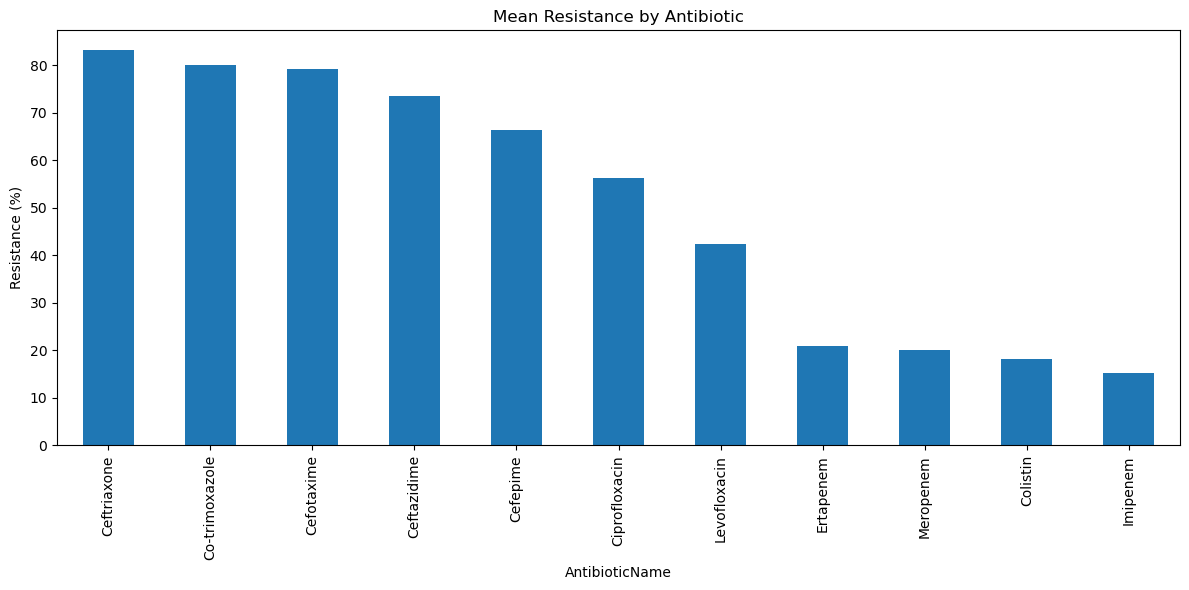

In [83]:
# ============================================
# PART 4B: PLOT MEAN RESISTANCE BY ANTIBIOTIC
# ============================================

plt.figure(figsize=(12,6))
abx_res.plot(kind='bar')
plt.title("Mean Resistance by Antibiotic")
plt.ylabel("Resistance (%)")
plt.xticks(rotation=90)
plt.tight_layout()
save_path=r"C:\Users\owner\Downloads\Mean Resistance by Antibiotic.png"
plt.savefig(save_path, dpi=300)
plt.show()

In [29]:
# ============================================
# PART 5A: TOP 10 HIGHEST RESISTANCE VALUES
# ============================================

top10 = (
    df.sort_values(by='ResistancePercentage', ascending=False)
      .head(10)
)

print("\n--- TOP 10 HIGHEST RESISTANCE OBSERVATIONS ---")
print(top10)


--- TOP 10 HIGHEST RESISTANCE OBSERVATIONS ---
        Specimen           PathogenName  AntibioticName Iso3  \
397  Bloodstream  Klebsiella pneumoniae        Cefepime  MWI   
57   Bloodstream  Klebsiella pneumoniae      Cefotaxime  NGA   
445  Bloodstream  Klebsiella pneumoniae  Co-trimoxazole  ZMB   
4    Bloodstream  Klebsiella pneumoniae        Cefepime  CIV   
5    Bloodstream  Klebsiella pneumoniae      Cefotaxime  CIV   
321  Bloodstream  Klebsiella pneumoniae        Colistin  CIV   
175  Bloodstream  Klebsiella pneumoniae  Co-trimoxazole  ZMB   
69   Bloodstream  Klebsiella pneumoniae  Co-trimoxazole  TZA   
134  Bloodstream  Klebsiella pneumoniae     Ceftriaxone  MOZ   
311  Bloodstream  Klebsiella pneumoniae     Ceftriaxone  BFA   

            CountryTerritoryArea   WHORegionName  InterpretableAST  Resistant  \
397                       Malawi  African Region                12         12   
57                       Nigeria  African Region                28         28   
445 

In [37]:
# ============================================
# PART 6A: YEARLY RESISTANCE TREND
# ============================================

year_trend = (
    df.groupby('Year')['ResistancePercentage']
      .mean()
)

print("\n--- RESISTANCE TREND BY YEAR ---")
print(year_trend)


--- RESISTANCE TREND BY YEAR ---
Year
2020    56.669886
2021    56.341528
2022    54.571888
2023    57.605422
Name: ResistancePercentage, dtype: float64


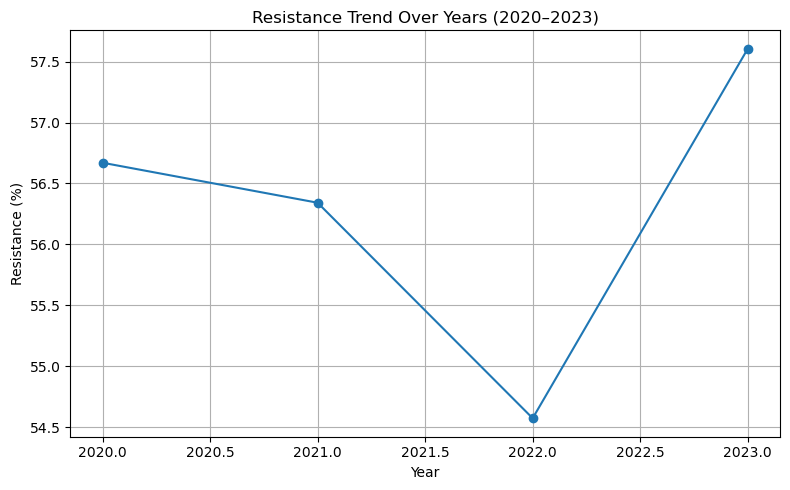

In [39]:
# ============================================
# PART 6B: PLOT RESISTANCE TREND OVER YEARS
# ============================================

plt.figure(figsize=(8,5))
plt.plot(year_trend.index, year_trend.values, marker='o')
plt.title("Resistance Trend Over Years (2020–2023)")
plt.ylabel("Resistance (%)")
plt.xlabel("Year")
plt.grid(True)
plt.tight_layout()
save_path=r"C:\Users\owner\Downloads\Resistance Trend Over Years (2020–2023).png"
plt.savefig(save_path, dpi=300)
plt.show()

In [53]:
# ============================================
# PART 7A: COUNTRY-YEAR PIVOT TABLE
# ============================================

pivot_country_year = df.pivot_table(
    values='ResistancePercentage',
    index='Year',
    columns='CountryTerritoryArea',
    aggfunc='mean'
)

print("\n--- COUNTRY × YEAR RESISTANCE PIVOT ---")
print(pivot_country_year)


--- COUNTRY × YEAR RESISTANCE PIVOT ---
CountryTerritoryArea    Algeria      Benin  Burkina Faso  \
Year                                                       
2020                        NaN        NaN     58.052338   
2021                        NaN        NaN     62.653375   
2022                        NaN  65.948159     45.962733   
2023                  44.013168  61.682279     75.616564   

CountryTerritoryArea  C<U+00F4>te d<U+2019>Ivoire   Cameroon  \
Year                                                           
2020                                    67.988381        NaN   
2021                                          NaN        NaN   
2022                                          NaN  59.826752   
2023                                    60.227273  53.608979   

CountryTerritoryArea  Democratic Republic of the Congo   Eswatini   Ethiopia  \
Year                                                                           
2020                                               Na

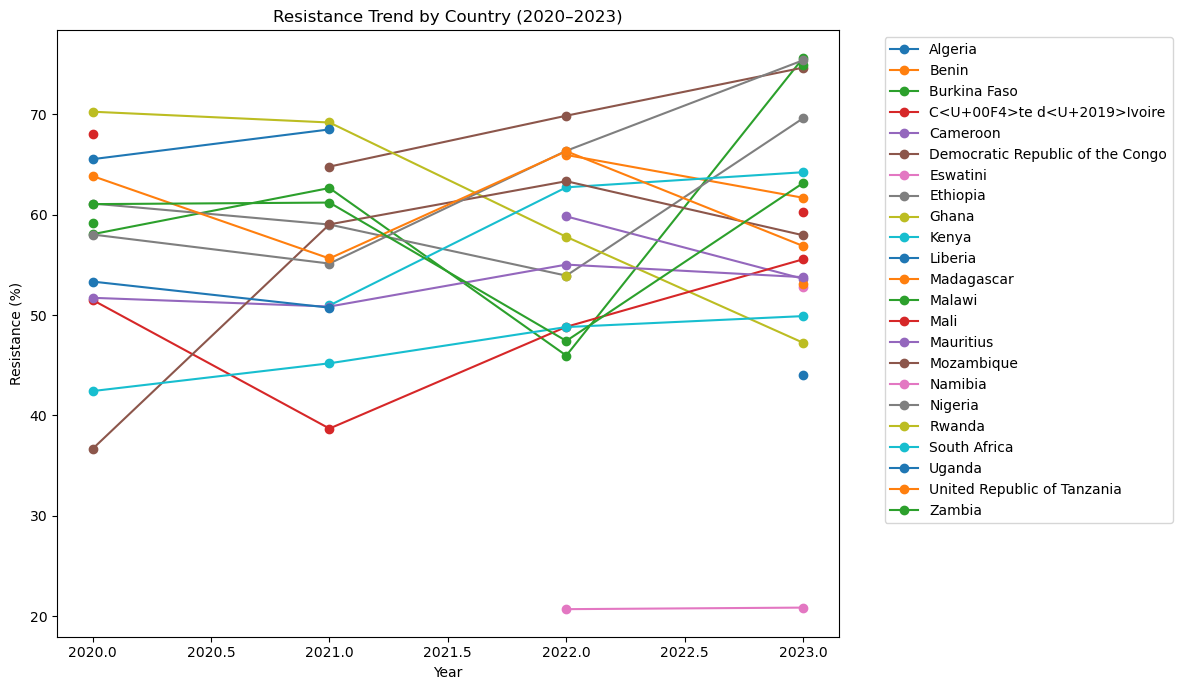

In [55]:
# ============================================
# PART 7B: PLOT RESISTANCE TREND BY COUNTRY
# ============================================

plt.figure(figsize=(12,7))

for country in pivot_country_year.columns:
    plt.plot(
        pivot_country_year.index, 
        pivot_country_year[country], 
        marker='o', 
        label=country
    )

plt.title("Resistance Trend by Country (2020–2023)")
plt.xlabel("Year")
plt.ylabel("Resistance (%)")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
save_path=r"C:\Users\owner\Downloads\Resistance Trend by Country (2020–2023).png"
plt.savefig(save_path, dpi=300)
plt.show()

In [47]:
# ============================================
# PART 8A: HEATMAP PIVOT TABLE
# ============================================

heat = df.pivot_table(
    values='ResistancePercentage',
    index='CountryTerritoryArea',
    columns='AntibioticName',
    aggfunc='mean'
)

print("\n--- HEATMAP DATA (COUNTRY × ANTIBIOTIC) ---")
print(heat)


--- HEATMAP DATA (COUNTRY × ANTIBIOTIC) ---
AntibioticName                     Cefepime  Cefotaxime  Ceftazidime  \
CountryTerritoryArea                                                   
Algeria                           65.151515   80.066445    80.000000   
Benin                             86.061947   88.460530    88.023225   
Burkina Faso                      67.222222   81.818182    80.978261   
C<U+00F4>te d<U+2019>Ivoire       87.500000   87.500000    84.558824   
Cameroon                          73.126735   86.290323    77.463415   
Democratic Republic of the Congo        NaN   90.037205          NaN   
Eswatini                          30.769231   74.074074    56.521739   
Ethiopia                          79.056010   89.839193    78.908467   
Ghana                                   NaN   81.403509    33.333333   
Kenya                             61.465413   87.724359    76.219512   
Liberia                           81.101190   84.090909    73.863636   
Madagascar         

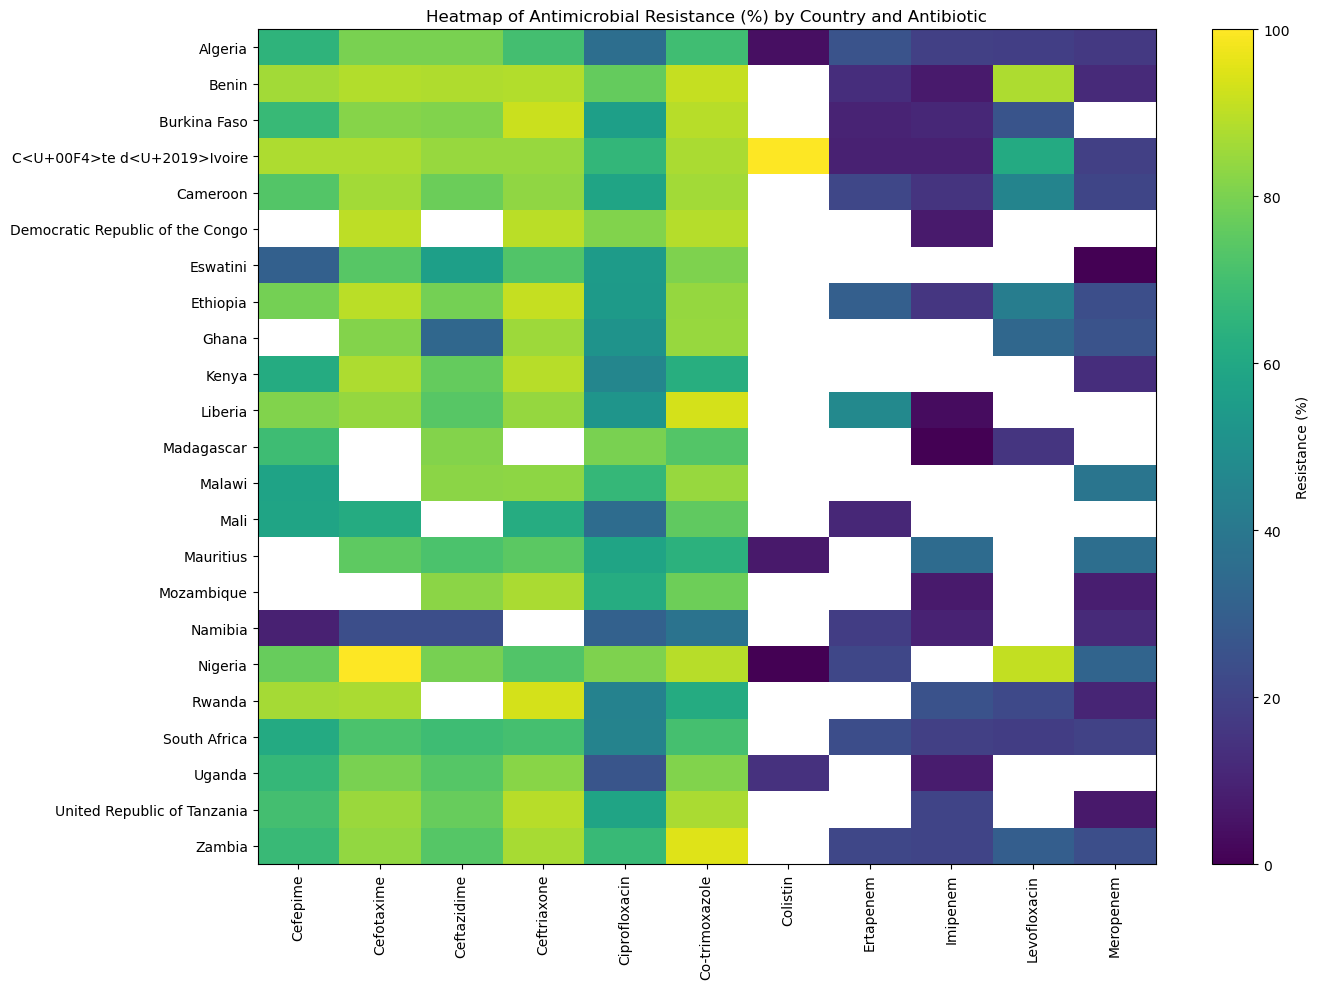

In [59]:
# ============================================
# PART 8B: PLOT HEATMAP
# ============================================

plt.figure(figsize=(14,10))
plt.imshow(heat, aspect='auto')
plt.colorbar(label="Resistance (%)")

plt.xticks(
    range(len(heat.columns)), 
    heat.columns, 
    rotation=90
)
plt.yticks(
    range(len(heat.index)), 
    heat.index
)

plt.title("Heatmap of Antimicrobial Resistance (%) by Country and Antibiotic")
plt.savefig(save_path, dpi=300)
plt.tight_layout()
plt.show()

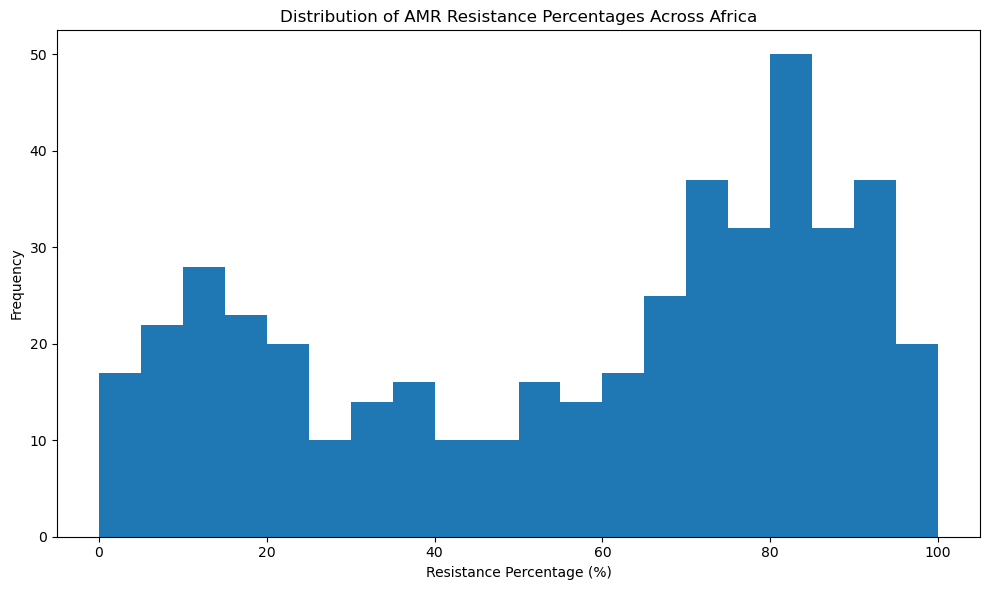

In [65]:
# ============================================
# PART 9A: HISTOGRAM OF RESISTANCE (%)
# ============================================

plt.figure(figsize=(10,6))
plt.hist(df['ResistancePercentage'].dropna(), bins=20)

plt.xlabel("Resistance Percentage (%)")
plt.ylabel("Frequency")
plt.title("Distribution of AMR Resistance Percentages Across Africa")

plt.tight_layout()
save_path=r"C:\Users\owner\Downloads\Distribution of AMR Resistance Percentages Across Africa.png"
plt.savefig(save_path, dpi=300)
plt.show()

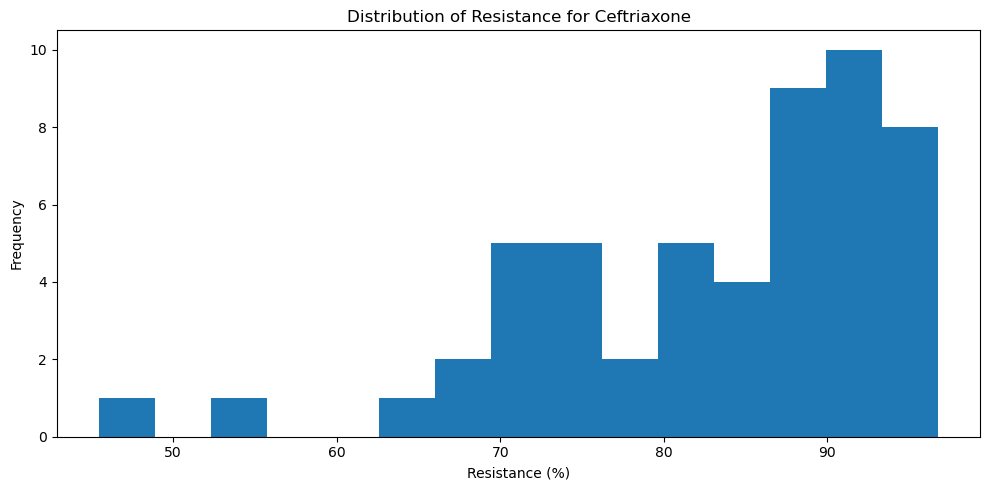

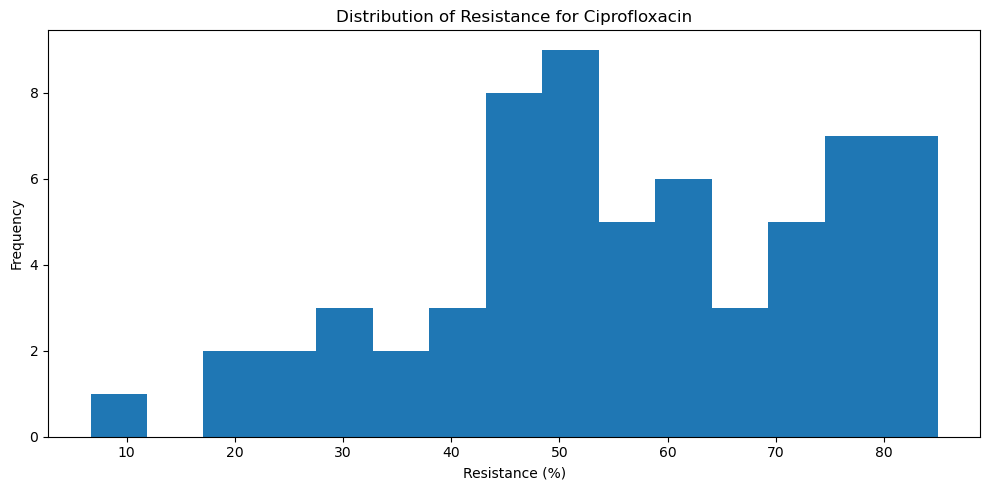

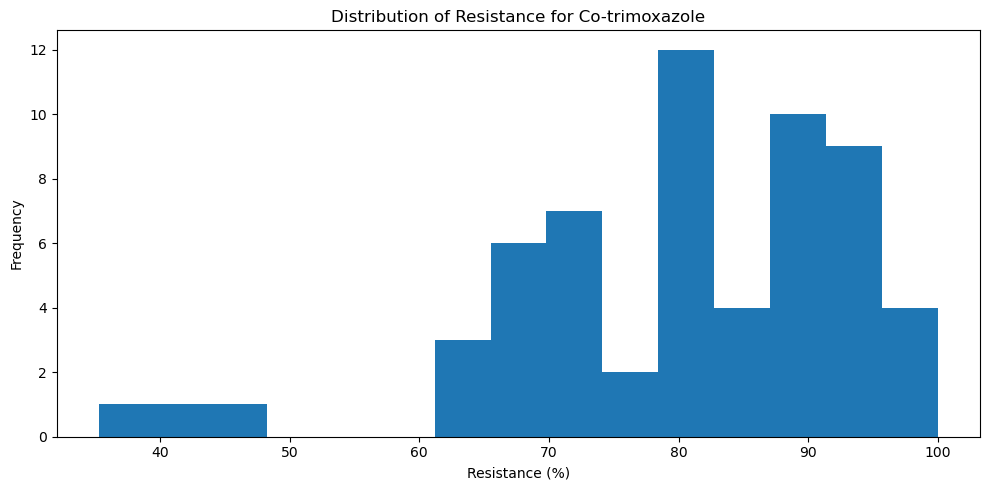

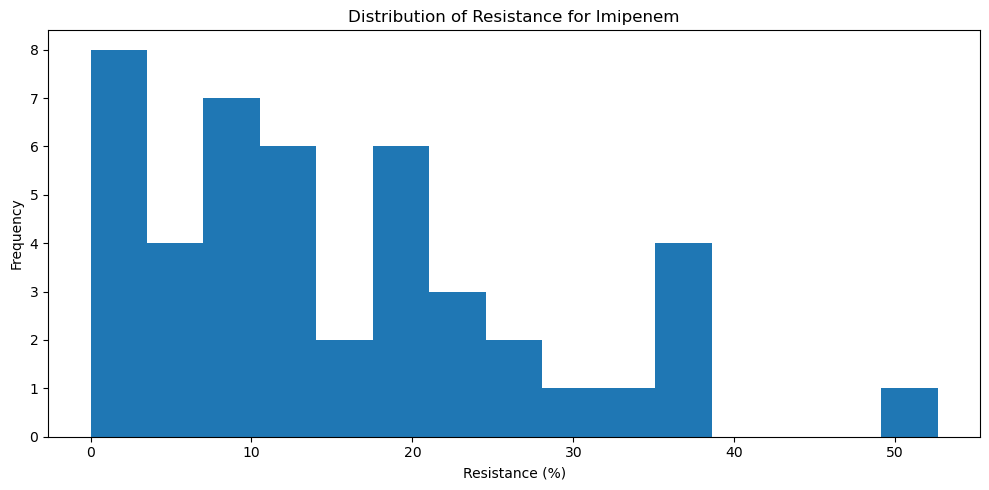

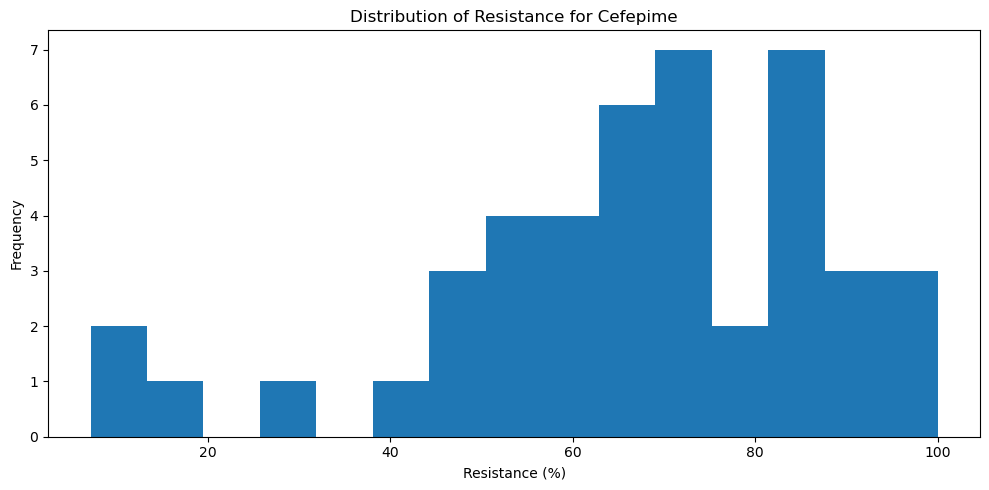

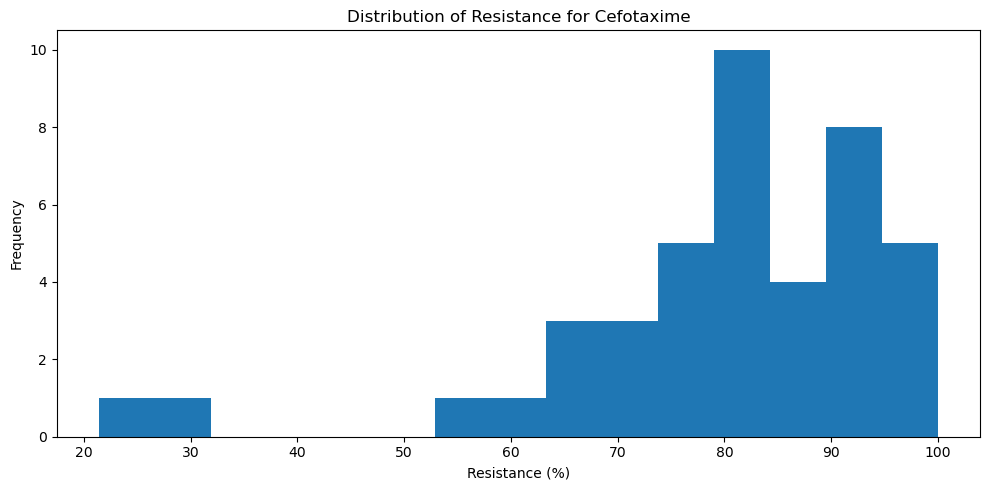

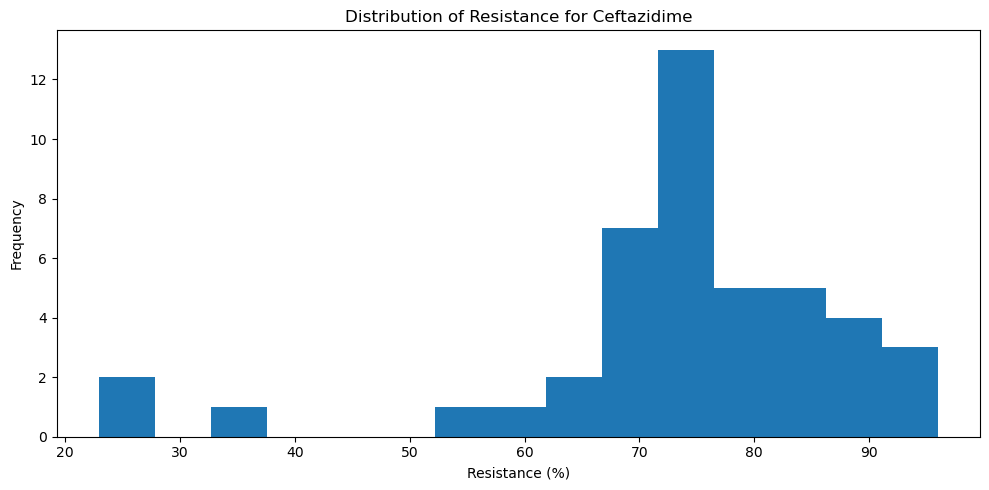

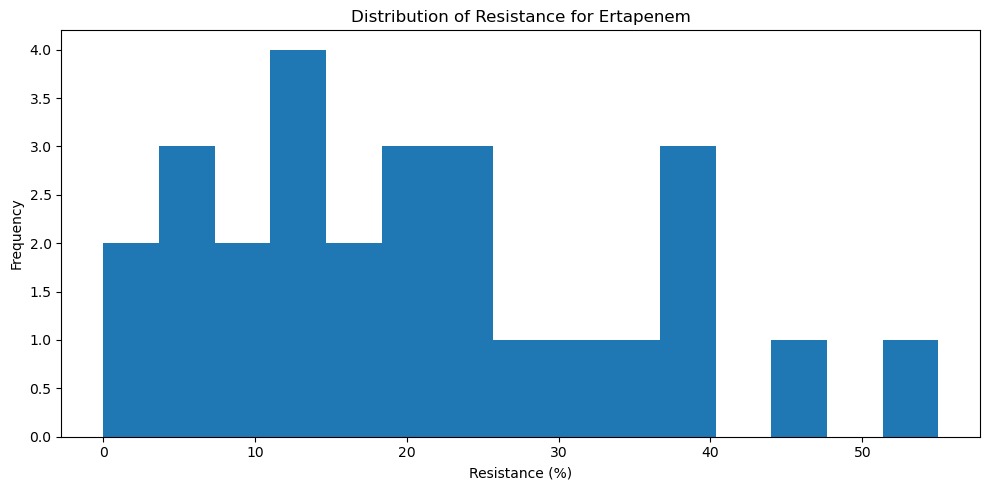

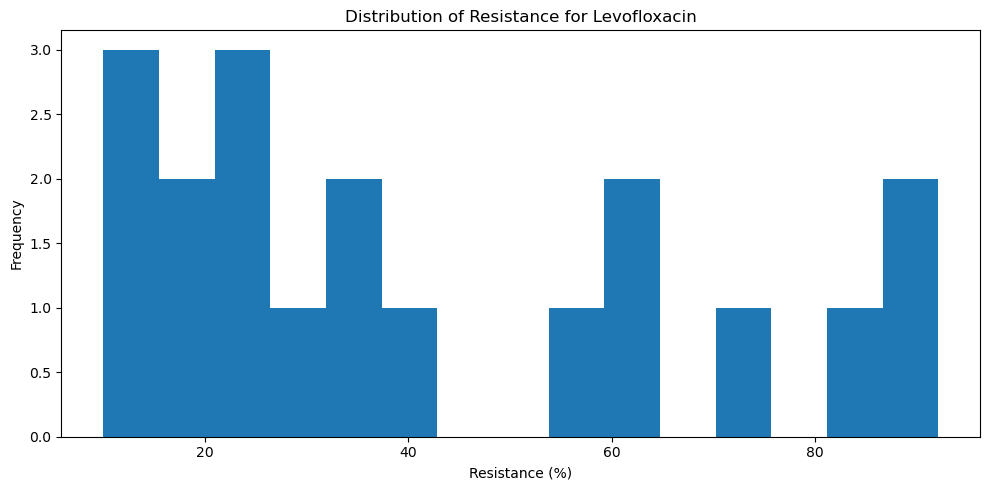

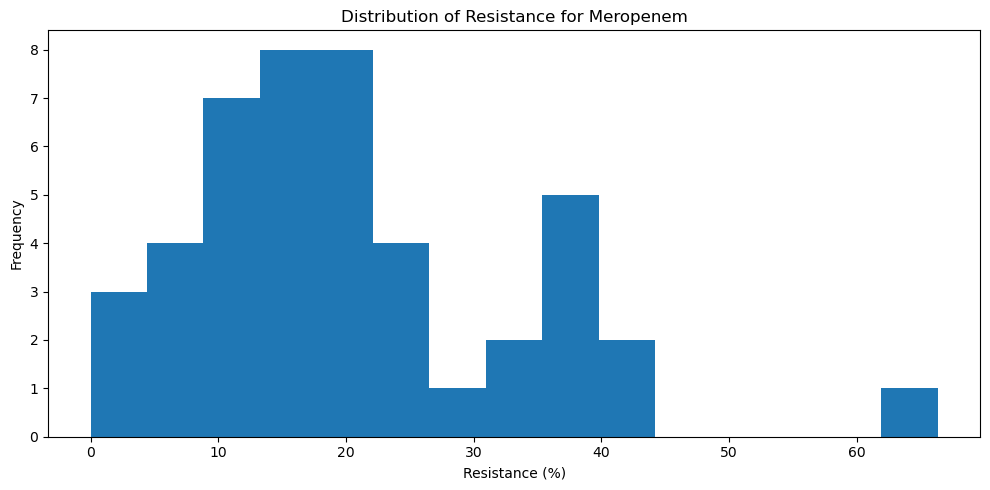

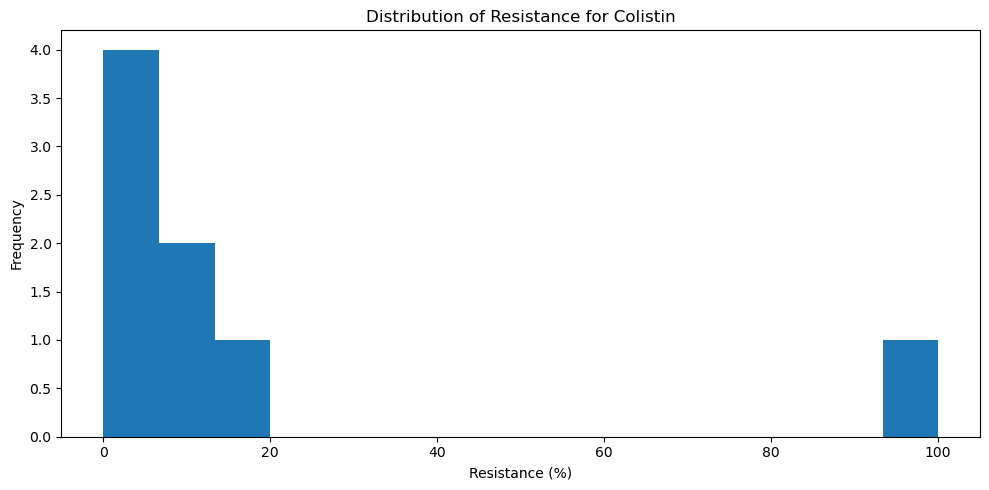

In [48]:
# ============================================
# PART 9B: HISTOGRAM BY ANTIBIOTIC
# ============================================

antibiotics = df['AntibioticName'].unique()

for ab in antibiotics:
    subset = df[df['AntibioticName'] == ab]['ResistancePercentage']

    plt.figure(figsize=(10,5))
    plt.hist(subset.dropna(), bins=15)
    
    plt.title(f"Distribution of Resistance for {ab}")
    plt.xlabel("Resistance (%)")
    plt.ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()

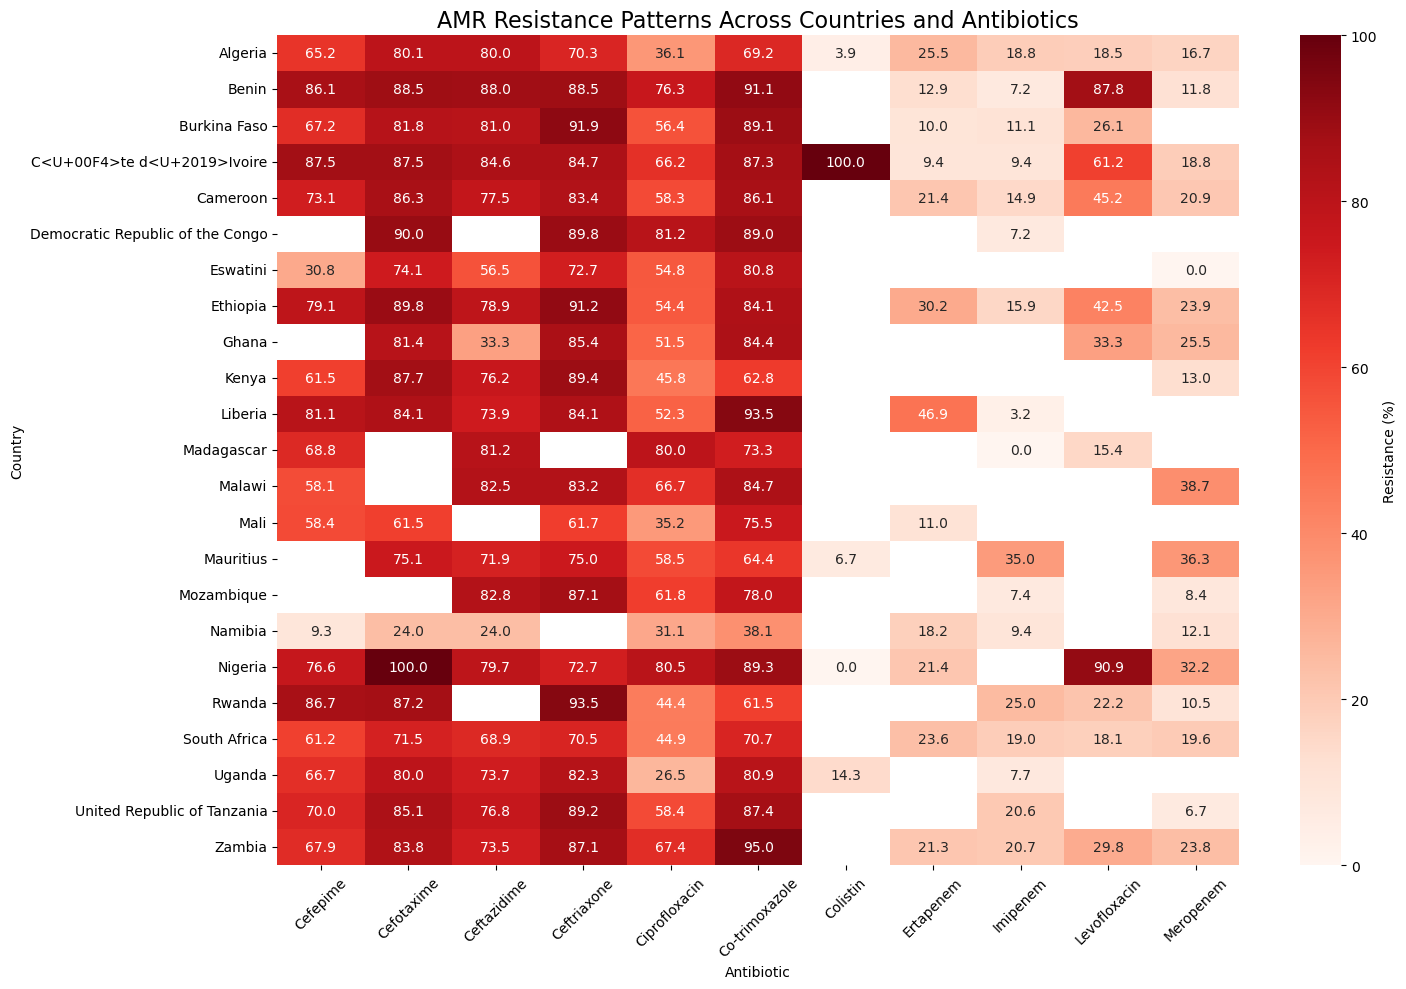

In [63]:
# Pivot the data for heatmap (average resistance per country and antibiotic)
heatmap_data = df.pivot_table(
    index='CountryTerritoryArea',
    columns='AntibioticName',
    values='ResistancePercentage',
    aggfunc='mean'
)

# Plotting the heatmap
plt.figure(figsize=(15,10))
sns.heatmap(
    heatmap_data, 
    annot=True,          # show numbers
    fmt=".1f",           # format to 1 decimal place
    cmap='Reds',         # red = higher resistance
    cbar_kws={'label': 'Resistance (%)'}
)
plt.title('AMR Resistance Patterns Across Countries and Antibiotics', fontsize=16)
plt.ylabel('Country')
plt.xlabel('Antibiotic')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
save_path=r"C:\Users\owner\Downloads\AMR Resistance Patterns Across Countries and Antibiotics.png"
plt.savefig(save_path, dpi=300)
plt.show()

In [56]:
plt.savefig("AMR Resistance Patterns Across Countries and Antibiotics.png")

<Figure size 640x480 with 0 Axes>

In [60]:
save_path=r"C:\Users\owner\Downloads\AMR Resistance Patterns Across Countries and Antibiotics.png"
plt.savefig(save_path, dpi=300)

<Figure size 640x480 with 0 Axes>